In [1]:
import superstats as sup

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/lschumacher/.local/share/uv/python/cpython-3.13.14-macos-aarch64-none/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:bayesflow:Using backend 'jax'


In [3]:
prior = sup.prior.JointPrior(
    v = sup.transition.RandomWalk(bounds=(0, 6)),
    a = sup.transition.RandomWalk(bounds=(0, 4)),
    tau = sup.prior.Prior("halfnormal", scale=0.5),
    bias = 0.5
)

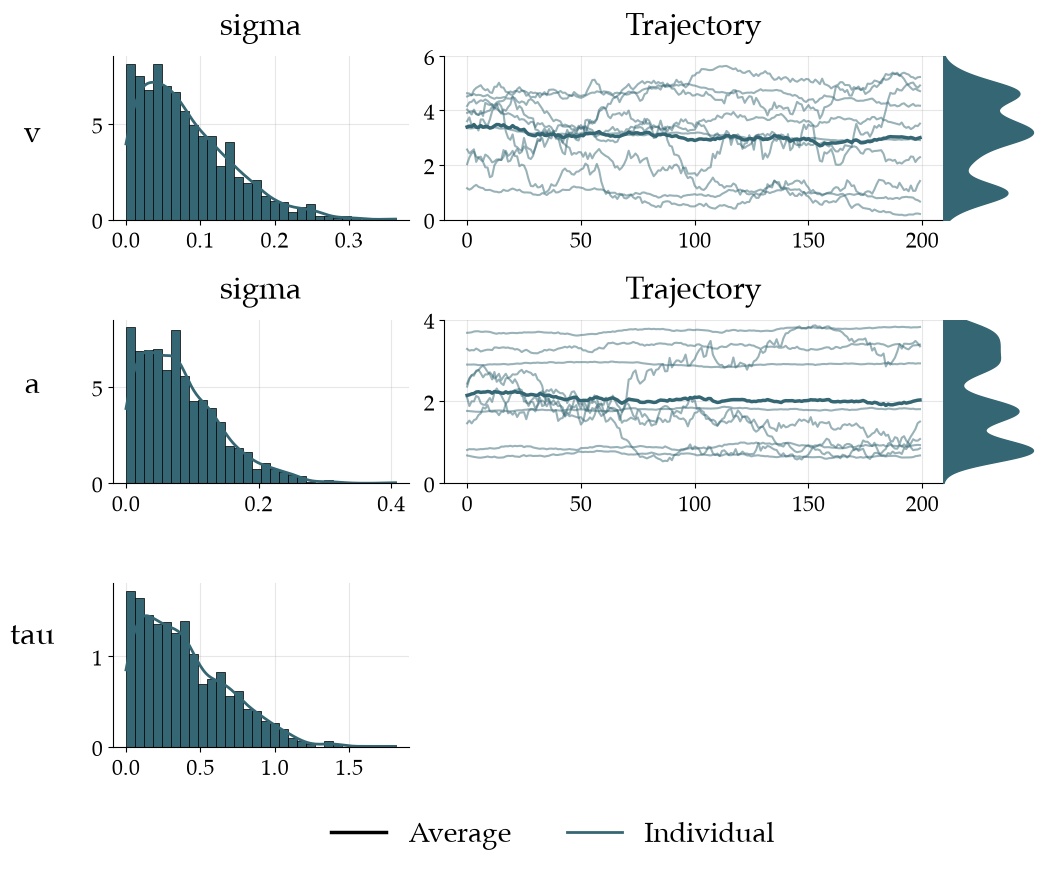

In [4]:
fig = prior.plot_joint_prior(num_trajectories=10, figsize=(10, 8))

# fig.savefig(
#     "joint_prior.pdf",
#     bbox_inches="tight",
    
# )

In [9]:
generative_model = sup.simulation.GenerativeModel(
    prior=prior,
    model=sup.simulation.cognitive.sample_ddm,
    missing_process=None
)

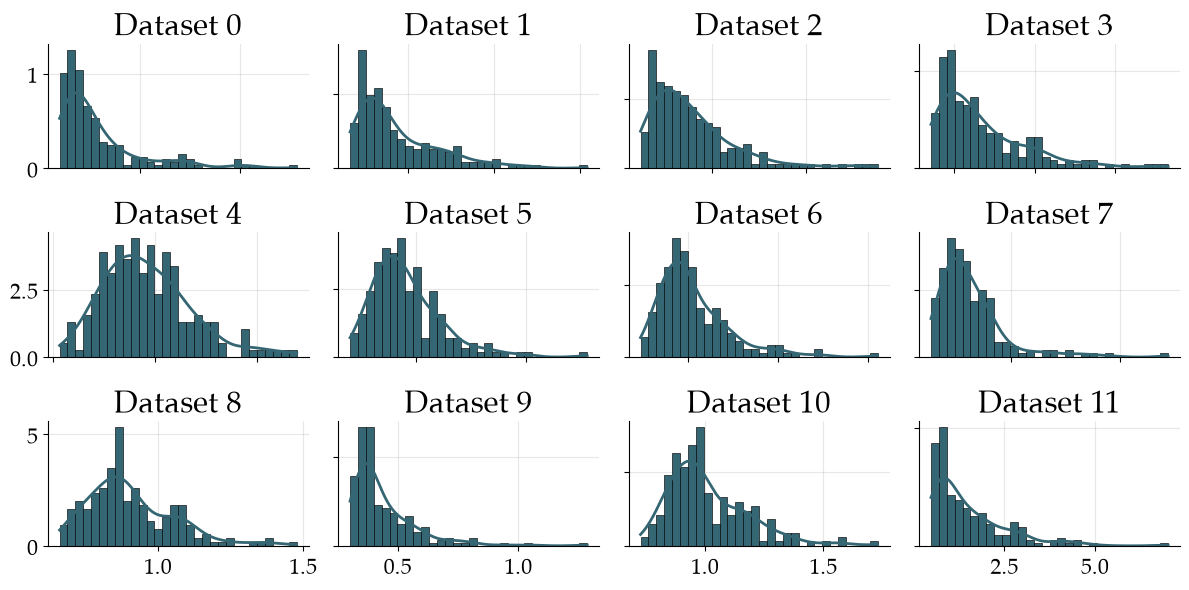

In [19]:
fig = generative_model.plot_push_forward(
    num_sim=12,
    num_steps=200,
    data_dim=0,
    kind="dist",
    aggregation=None,
    num_cols=4,
    figsize=(12, 6)
)

In [20]:
fig.savefig(
    "push_forward_check.pdf",
    bbox_inches="tight"
    
)